# Customer Segmentation & Retention — An End-to-End E-commerce Project

> **Goal:** take raw transactional data from a real online retailer and turn it into an actionable customer segmentation that a marketing or CRM team could use *tomorrow*. We go all the way from messy invoice lines → RFM features → clusters → named personas → retention recommendations.

---

## Why this matters in production

Every e-commerce company has the same core problem: **not all customers are the same, and you can't treat them the same.** A "spray-and-pray" email to your entire base wastes budget on people who already churned and annoys your best customers with irrelevant offers.

Segmentation answers three operational questions:

1. **Who are my best customers?** (so I protect and reward them)
2. **Who is about to leave?** (so I intervene *before* they're gone)
3. **Who is already lost?** (so I stop spending on them, or run a cheap win-back)

The most battle-tested framework for this is **RFM** — Recency, Frequency, Monetary — because it needs nothing but a transaction log (which every company has) and maps directly to marketing action. We'll build RFM first as an interpretable baseline, then layer **K-Means clustering** on top to discover natural groupings the rigid scoring rules would miss.

### Roadmap
| Step | What | Why |
|---|---|---|
| 1 | Load & understand raw data | You can't model what you don't understand |
| 2 | Data cleaning | Cancellations, returns, missing IDs — the unglamorous 80% |
| 3 | Build RFM features | Turn transactions → one row per customer |
| 4 | RFM quantile scoring | Interpretable, rule-based baseline |
| 5 | K-Means clustering | Data-driven segments |
| 6 | Name the personas | Translate clusters → business language |
| 7 | Retention strategy | What to *do* with each segment |

---
## The dataset

We use the **UCI Online Retail** dataset: all transactions for a UK-based online gift retailer between **Dec 2010 and Dec 2011**. It's the canonical dataset for this task — real, messy, and large enough (~540K rows) to be realistic. License: CC BY 4.0.

> The notebook auto-downloads the data, so it runs anywhere with no manual setup.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.titlesize'] = 13
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

RANDOM_STATE = 42

### 1. Load the raw data

The data is hosted in a public GitHub mirror, so anyone who clones this repo can run it immediately.

In [2]:
URL = ("https://raw.githubusercontent.com/databricks/Spark-The-Definitive-Guide/"
       "master/data/retail-data/all/online-retail-dataset.csv")

df = pd.read_csv(URL, encoding='ISO-8859-1')
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'], format='%m/%d/%Y %H:%M')

print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
df.head()

Shape: 541,909 rows x 8 columns


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,"17,850.00",United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,"17,850.00",United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,"17,850.00",United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,"17,850.00",United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,"17,850.00",United Kingdom


Each row is a **single product line within an invoice** — not one row per customer or per order. One invoice (`InvoiceNo`) can span many rows. We'll need to aggregate up to the customer level later.

**Column meanings:**
- `InvoiceNo` — order ID. If it starts with **`C`**, it's a **cancellation** (a return).
- `StockCode` / `Description` — the product.
- `Quantity` — units in that line (can be **negative** for returns).
- `InvoiceDate` — timestamp.
- `UnitPrice` — price per unit (£).
- `CustomerID` — the customer. **Can be missing** (guest / unregistered checkouts).
- `Country` — billing country.

In [3]:
df.info()
print("\n--- Missing values ---")
print(df.isna().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB

--- Missing values ---
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64


### 2. Understand the mess *before* cleaning

A senior data scientist never deletes rows blindly. First we quantify each problem so we understand what we're throwing away and why.

In [4]:
n = len(df)
issues = {
    'Cancellations (InvoiceNo starts with C)': df['InvoiceNo'].astype(str).str.startswith('C').sum(),
    'Missing CustomerID':                      df['CustomerID'].isna().sum(),
    'Negative or zero Quantity':               (df['Quantity'] <= 0).sum(),
    'Zero or negative UnitPrice':              (df['UnitPrice'] <= 0).sum(),
    'Duplicate rows':                          df.duplicated().sum(),
}
for k, v in issues.items():
    print(f"{k:<45} {v:>7,}  ({v/n*100:4.1f}%)")

Cancellations (InvoiceNo starts with C)         9,288  ( 1.7%)
Missing CustomerID                            135,080  (24.9%)
Negative or zero Quantity                      10,624  ( 2.0%)
Zero or negative UnitPrice                      2,517  ( 0.5%)
Duplicate rows                                  5,268  ( 1.0%)


**How we handle each, and why:**

- **Cancellations / negative quantities** → for a *segmentation* of purchasing behaviour we drop them. (In a churn or CLV model you'd instead net them against purchases — returns are signal. We keep this project focused.)
- **Missing `CustomerID`** → ~25% of rows. We **cannot** assign these to a customer, and segmentation is *per customer*, so they must go. This is a big chunk — worth flagging to stakeholders, because it means a quarter of revenue is anonymous.
- **Zero/negative price** → bad debt adjustments, freebies, data-entry errors. Drop.
- **Duplicates** → exact-duplicate lines are almost always ingestion artifacts. Drop.

In [5]:
df_clean = df.copy()
df_clean['InvoiceNo'] = df_clean['InvoiceNo'].astype(str)

df_clean = df_clean[~df_clean['InvoiceNo'].str.startswith('C')]   # drop cancellations
df_clean = df_clean.dropna(subset=['CustomerID'])                 # need a customer
df_clean = df_clean[df_clean['Quantity'] > 0]                     # real purchases
df_clean = df_clean[df_clean['UnitPrice'] > 0]                    # valid price
df_clean = df_clean.drop_duplicates()

df_clean['CustomerID'] = df_clean['CustomerID'].astype(int)
df_clean['Revenue'] = df_clean['Quantity'] * df_clean['UnitPrice']

print(f"Rows: {len(df):,} -> {len(df_clean):,} "
      f"({len(df_clean)/len(df)*100:.0f}% retained)")
print(f"Unique customers: {df_clean['CustomerID'].nunique():,}")
print(f"Date range: {df_clean['InvoiceDate'].min().date()} "
      f"to {df_clean['InvoiceDate'].max().date()}")

Rows: 541,909 -> 392,692 (72% retained)
Unique customers: 4,338
Date range: 2010-12-01 to 2011-12-09


### 3. A quick look at the business

Before modeling customers, sanity-check the business itself. These plots are also what you'd put in front of a stakeholder to build trust in the data.

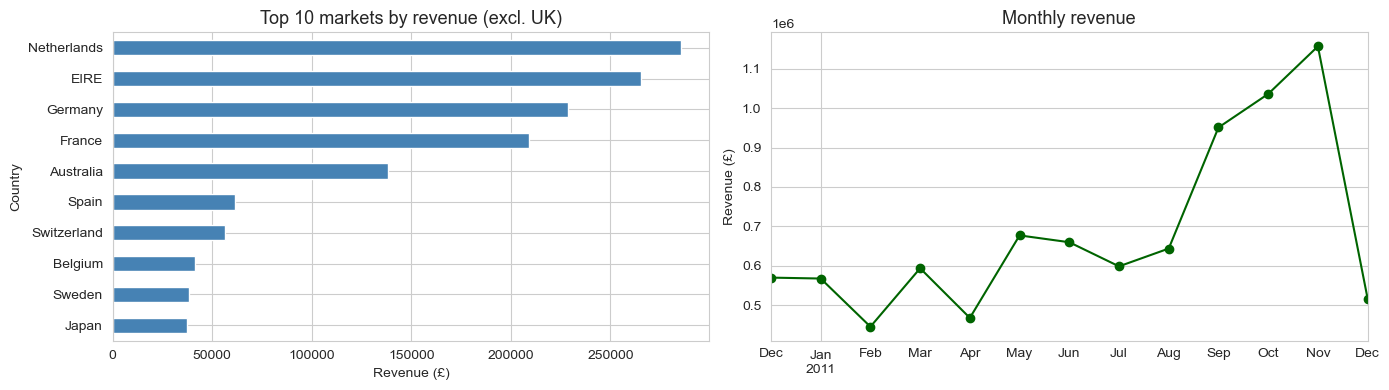

The UK alone is 82% of all revenue — this is a UK business with an export tail.


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Revenue by country (top 10, excluding UK which dominates)
country_rev = (df_clean.groupby('Country')['Revenue'].sum()
               .sort_values(ascending=False))
country_rev.drop('United Kingdom').head(10).plot.barh(ax=axes[0], color='steelblue')
axes[0].set_title('Top 10 markets by revenue (excl. UK)')
axes[0].set_xlabel('Revenue (£)')
axes[0].invert_yaxis()

# Monthly revenue trend
monthly = df_clean.set_index('InvoiceDate')['Revenue'].resample('ME').sum()
monthly.plot(ax=axes[1], marker='o', color='darkgreen')
axes[1].set_title('Monthly revenue')
axes[1].set_xlabel('')
axes[1].set_ylabel('Revenue (£)')
plt.tight_layout(); plt.show()

uk_share = country_rev['United Kingdom'] / country_rev.sum() * 100
print(f"The UK alone is {uk_share:.0f}% of all revenue — this is a UK business with an export tail.")

> **Note the December 2011 dip** — the data ends on the 9th, so that month is incomplete. Always check your date boundaries before trusting the last data point. This exact trap (treating a partial period as a real decline) causes endless false alarms in production dashboards.

---
## 4. Building RFM features

This is the heart of the project: collapsing the transaction log into **one row per customer** with three behavioural features.

| Feature | Definition | Business meaning | Good value |
|---|---|---|---|
| **Recency** | Days since the customer's *last* purchase | How "alive" is this relationship? | **Low** |
| **Frequency** | Number of *distinct orders* | How engaged / habitual are they? | **High** |
| **Monetary** | Total money spent | How valuable are they? | **High** |

**Recency** is computed relative to a fixed **snapshot date** — one day after the last transaction in the data, simulating "today" if we were running this the morning after the data was collected. Using a fixed snapshot (not `datetime.now()`) makes the analysis **reproducible**: re-running it next year gives the same Recency.

In [7]:
snapshot_date = df_clean['InvoiceDate'].max() + pd.Timedelta(days=1)
print(f"Snapshot ('today'): {snapshot_date.date()}")

rfm = df_clean.groupby('CustomerID').agg(
    Recency   = ('InvoiceDate', lambda x: (snapshot_date - x.max()).days),
    Frequency = ('InvoiceNo', 'nunique'),     # distinct orders, NOT line items
    Monetary  = ('Revenue', 'sum'),
).reset_index()

print(f"\n{len(rfm):,} customers, one row each")
rfm.head()

Snapshot ('today'): 2011-12-10

4,338 customers, one row each


,CustomerID,Recency,Frequency,Monetary
0,12346,326,1,"77,183.60"
1,12347,2,7,"4,310.00"
2,12348,75,4,"1,797.24"
3,12349,19,1,"1,757.55"
4,12350,310,1,334.40


> **Subtle but important:** `Frequency` uses `nunique` on `InvoiceNo`, counting **distinct orders**, not line items. A customer who buys 30 products in one order has Frequency = 1, not 30. Getting this wrong (a common junior mistake) massively inflates frequency for bulk buyers and corrupts the whole segmentation.

In [8]:
rfm[['Recency', 'Frequency', 'Monetary']].describe()

,Recency,Frequency,Monetary
count,"4,338.00","4,338.00","4,338.00"
mean,92.54,4.27,"2,048.69"
std,100.01,7.70,"8,985.23"
min,1.00,1.00,3.75
25%,18.00,1.00,306.48
50%,51.00,2.00,668.57
75%,142.00,5.00,"1,660.60"
max,374.00,209.00,"280,206.02"


The distributions are extremely **right-skewed** — classic for customer data. The median customer placed **2 orders** and spent **~£675**, but the max is **209 orders** and **£280,000** (these are wholesalers). Let's see it.

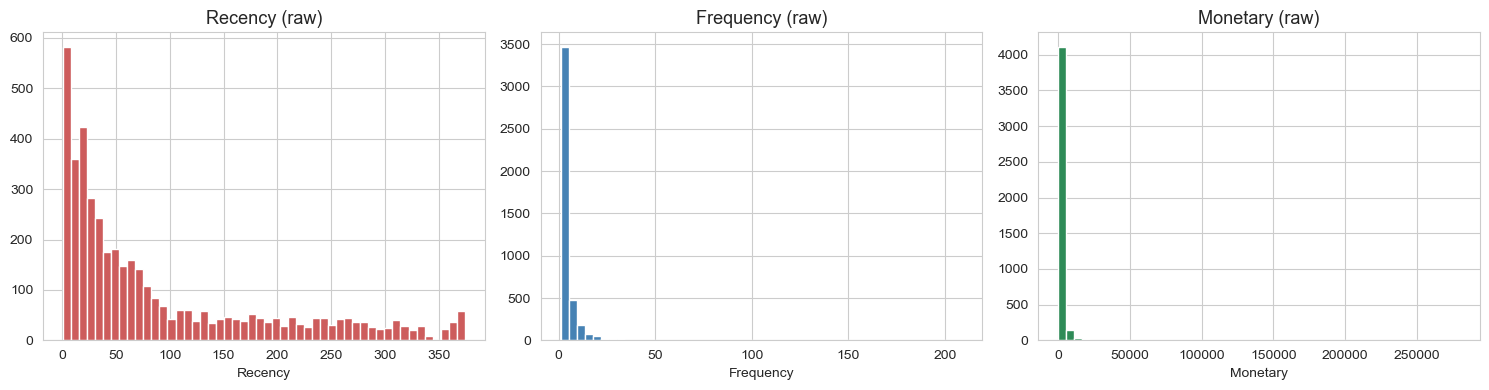

Heavy right skew on F and M. We'll handle this two ways: quantile scoring (rank-based, immune to skew) and a log transform before K-Means (which assumes roughly spherical clusters).


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col, color in zip(axes, ['Recency', 'Frequency', 'Monetary'],
                          ['indianred', 'steelblue', 'seagreen']):
    ax.hist(rfm[col], bins=50, color=color, edgecolor='white')
    ax.set_title(f'{col} (raw)')
    ax.set_xlabel(col)
plt.tight_layout(); plt.show()
print("Heavy right skew on F and M. We'll handle this two ways: quantile scoring (rank-based, "
      "immune to skew) and a log transform before K-Means (which assumes roughly spherical clusters).")

---
## 5. RFM quantile scoring — the interpretable baseline

Before any machine learning, build the **rule-based** version. It's transparent, needs no tuning, and a marketing manager can understand it in 30 seconds. Always ship the simple baseline first.

**The idea:** split each dimension into 5 quantiles (quintiles) and score 1–5.
- **Recency:** *lower is better*, so the most-recent 20% get **R=5**.
- **Frequency & Monetary:** *higher is better*, so the top 20% get **5**.

A customer with `R=5, F=5, M=5` is a dream; `1,1,1` is essentially gone.

In [10]:
# Recency: low = good -> reverse the labels
rfm['R'] = pd.qcut(rfm['Recency'], 5, labels=[5, 4, 3, 2, 1]).astype(int)

# Frequency: many ties at 1-2 orders, so rank first to break them before binning
rfm['F'] = pd.qcut(rfm['Frequency'].rank(method='first'), 5,
                   labels=[1, 2, 3, 4, 5]).astype(int)

rfm['M'] = pd.qcut(rfm['Monetary'], 5, labels=[1, 2, 3, 4, 5]).astype(int)

rfm['RFM_Score'] = rfm['R'] + rfm['F'] + rfm['M']   # 3 (worst) .. 15 (best)
rfm[['CustomerID', 'Recency', 'Frequency', 'Monetary', 'R', 'F', 'M', 'RFM_Score']].head()

,CustomerID,Recency,Frequency,Monetary,R,F,M,RFM_Score
0,12346,326,1,"77,183.60",1,1,5,7
1,12347,2,7,"4,310.00",5,5,5,15
2,12348,75,4,"1,797.24",2,4,4,10
3,12349,19,1,"1,757.55",4,1,4,9
4,12350,310,1,334.40,1,1,2,4


> **Why `.rank(method='first')` on Frequency?** So many customers have exactly 1 or 2 orders that `qcut` can't find 5 clean quantile edges — it would error on duplicate bin boundaries. Ranking first spreads the ties so the cut succeeds. This is the kind of practical detail that separates code that runs from code that crashes on real data.

We can map the score to simple tiers for a first, no-ML segmentation:

In [11]:
def rfm_tier(score):
    if score >= 13: return '01 Champions'
    if score >= 10: return '02 Loyal'
    if score >= 7:  return '03 Potential'
    if score >= 5:  return '04 At Risk'
    return '05 Lost'

rfm['Tier'] = rfm['RFM_Score'].apply(rfm_tier)

tier_summary = rfm.groupby('Tier').agg(
    Customers=('CustomerID', 'count'),
    Avg_Recency=('Recency', 'mean'),
    Avg_Frequency=('Frequency', 'mean'),
    Avg_Monetary=('Monetary', 'mean'),
    Total_Revenue=('Monetary', 'sum'),
).round(1)
tier_summary['Rev_Share_%'] = (tier_summary['Total_Revenue'] /
                               tier_summary['Total_Revenue'].sum() * 100).round(1)
tier_summary

,Customers,Avg_Recency,Avg_Frequency,Avg_Monetary,Total_Revenue,Rev_Share_%
Tier,,,,,,
01 Champions,933,14.60,11.80,"6,689.80","6,241,545.80",70.20
02 Loyal,1010,43.40,3.90,"1,389.10","1,403,001.60",15.80
03 Potential,1088,85.50,2.00,807.00,"878,035.70",9.90
04 At Risk,763,147.30,1.20,341.40,"260,496.20",2.90
05 Lost,544,254.50,1.00,191.40,"104,129.60",1.20


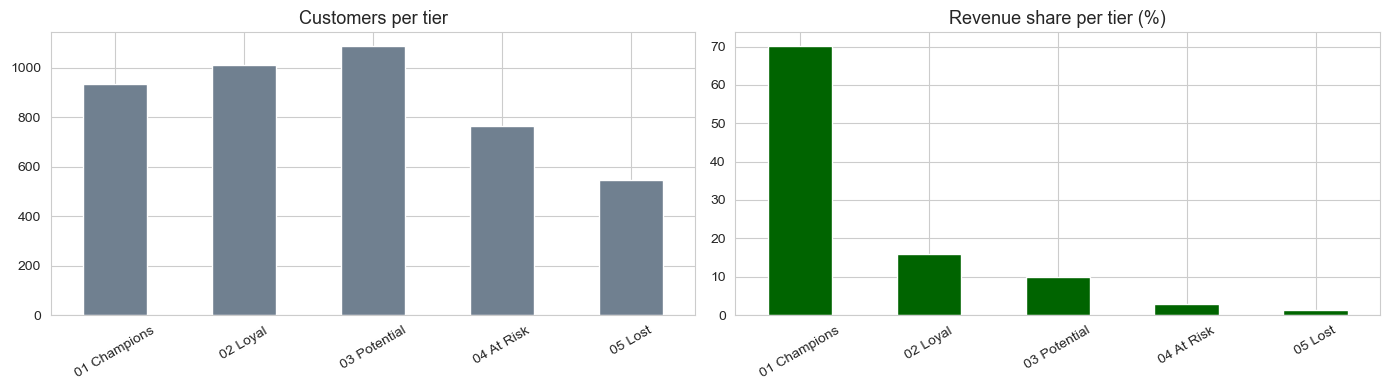

Classic Pareto: a small group of Champions drives a hugely disproportionate share of revenue.


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
order = sorted(rfm['Tier'].unique())
rfm['Tier'].value_counts()[order].plot.bar(ax=axes[0], color='slategray')
axes[0].set_title('Customers per tier'); axes[0].set_xlabel(''); axes[0].tick_params(axis='x', rotation=30)

tier_summary.loc[order, 'Rev_Share_%'].plot.bar(ax=axes[1], color='darkgreen')
axes[1].set_title('Revenue share per tier (%)'); axes[1].set_xlabel(''); axes[1].tick_params(axis='x', rotation=30)
plt.tight_layout(); plt.show()
print("Classic Pareto: a small group of Champions drives a hugely disproportionate share of revenue.")

This is already useful and shippable. But notice the limitation: the **boundaries are arbitrary** (why 13? why 10?) and we treated R, F, M as equally weighted and independent. Real customer groups have *correlated* structure — e.g. high-frequency buyers who shop in bursts. To discover those natural groupings, we move to clustering.

---
## 6. K-Means clustering — letting the data define the segments

K-Means finds groups by minimizing within-cluster distance. Two things must be handled first or it will give garbage:

1. **Skew** — K-Means uses Euclidean distance, so the £280K wholesaler would dominate everything. We **log-transform** to compress the tail.
2. **Scale** — Monetary is in the thousands, Frequency in single digits. Without standardizing, Monetary alone decides the clusters. We **standardize** to mean 0, std 1.

> Order matters: **log first, then standardize.**

In [13]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

X = rfm[['Recency', 'Frequency', 'Monetary']].copy()
X_log = np.log1p(X)                      # log1p handles any zeros safely
X_scaled = StandardScaler().fit_transform(X_log)

print("After log + standardize (should be ~0 mean, ~1 std):")
print(pd.DataFrame(X_scaled, columns=X.columns).describe().loc[['mean', 'std']].round(2))

After log + standardize (should be ~0 mean, ~1 std):
      Recency  Frequency  Monetary
mean    -0.00      -0.00     -0.00
std      1.00       1.00      1.00


### Choosing *k*: elbow + silhouette\n\nWe don't guess the number of clusters — we let two diagnostics guide us.\n- **Elbow (inertia):** total within-cluster distance. Look for the "elbow" where adding clusters stops helping much.\n- **Silhouette:** how well-separated the clusters are (higher = better, max 1).

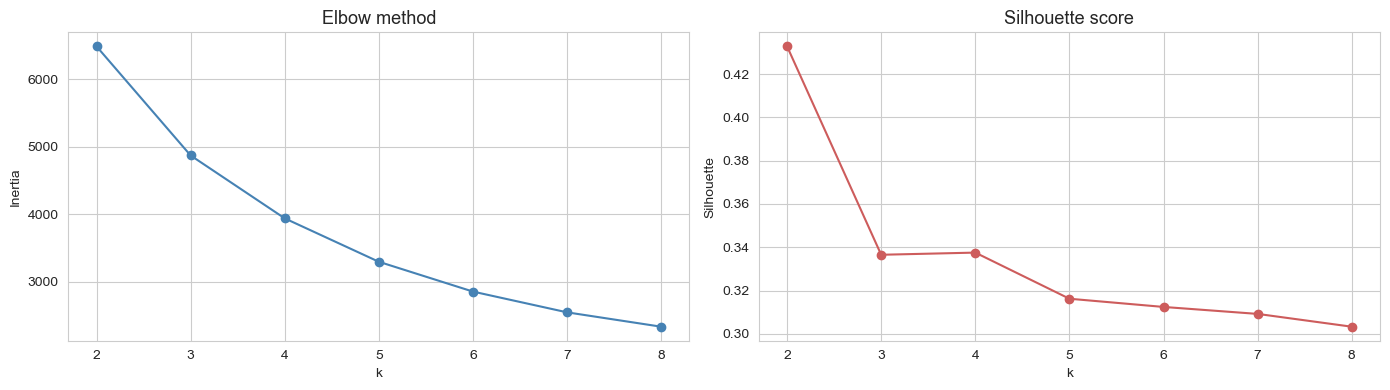

k=2: silhouette=0.433
k=3: silhouette=0.337
k=4: silhouette=0.338
k=5: silhouette=0.316
k=6: silhouette=0.312
k=7: silhouette=0.309
k=8: silhouette=0.303


In [14]:
inertias, silhouettes = [], []
K_range = range(2, 9)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10).fit(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(list(K_range), inertias, 'o-', color='steelblue')
axes[0].set_title('Elbow method'); axes[0].set_xlabel('k'); axes[0].set_ylabel('Inertia')
axes[1].plot(list(K_range), silhouettes, 'o-', color='indianred')
axes[1].set_title('Silhouette score'); axes[1].set_xlabel('k'); axes[1].set_ylabel('Silhouette')
plt.tight_layout(); plt.show()

for k, s in zip(K_range, silhouettes):
    print(f"k={k}: silhouette={s:.3f}")

Silhouette is highest at k=2, but two clusters ("good" vs "bad") is too coarse to be *actionable* — you can't build distinct campaigns from it. **k=4** sits at the elbow, keeps a healthy silhouette, and yields four groups that map cleanly onto recognizable marketing personas. This is a key judgment call: **the statistically optimal k is not always the operationally useful k.** We choose for business value, then verify the clusters are still well-separated.

In [15]:
K = 4
kmeans = KMeans(n_clusters=K, random_state=RANDOM_STATE, n_init=10)
rfm['Cluster'] = kmeans.fit_predict(X_scaled)

cluster_profile = rfm.groupby('Cluster').agg(
    Customers=('CustomerID', 'count'),
    Recency=('Recency', 'mean'),
    Frequency=('Frequency', 'mean'),
    Monetary=('Monetary', 'mean'),
).round(1)
cluster_profile['Rev_Share_%'] = (
    rfm.groupby('Cluster')['Monetary'].sum() /
    rfm['Monetary'].sum() * 100).round(1)
cluster_profile

,Customers,Recency,Frequency,Monetary,Rev_Share_%
Cluster,,,,,
0,713,12.20,13.80,"8,088.00",64.90
1,1622,181.50,1.30,341.00,6.20
2,837,17.70,2.20,557.30,5.20
3,1166,71.60,4.10,"1,801.80",23.60


### Visualizing the clusters

Three features are hard to see at once. We plot the two most decision-relevant pairs and size points by Monetary.

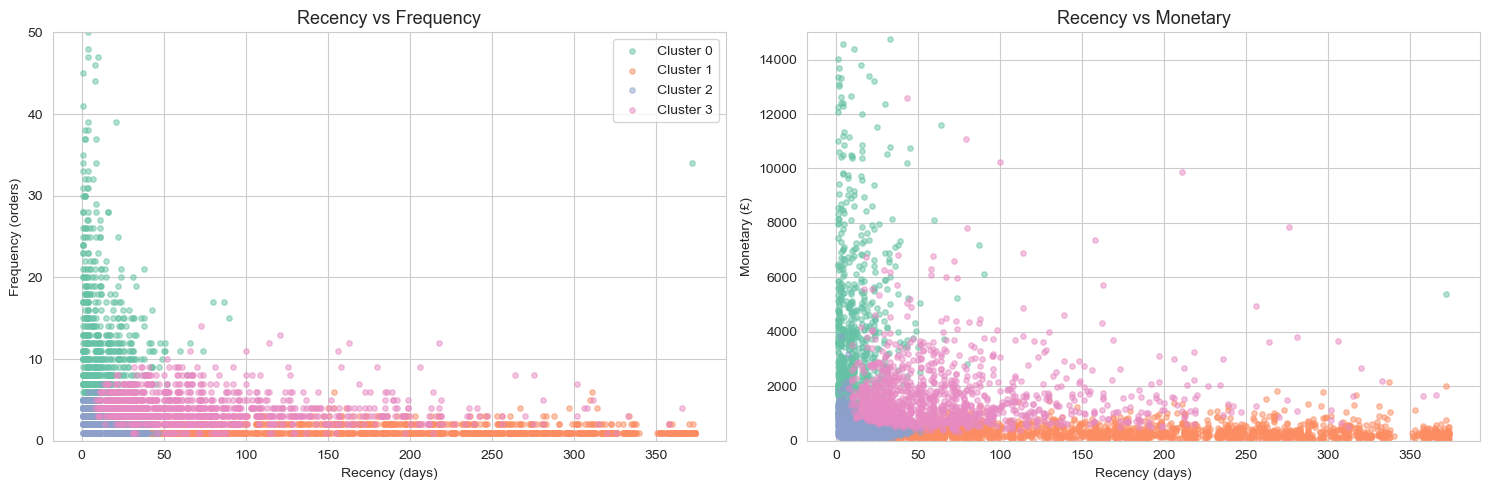

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
palette = sns.color_palette('Set2', K)

for c in range(K):
    sub = rfm[rfm['Cluster'] == c]
    axes[0].scatter(sub['Recency'], sub['Frequency'], s=15, alpha=0.5,
                    color=palette[c], label=f'Cluster {c}')
axes[0].set_xlabel('Recency (days)'); axes[0].set_ylabel('Frequency (orders)')
axes[0].set_title('Recency vs Frequency'); axes[0].set_ylim(0, 50); axes[0].legend()

for c in range(K):
    sub = rfm[rfm['Cluster'] == c]
    axes[1].scatter(sub['Recency'], sub['Monetary'], s=15, alpha=0.5, color=palette[c])
axes[1].set_xlabel('Recency (days)'); axes[1].set_ylabel('Monetary (£)')
axes[1].set_title('Recency vs Monetary'); axes[1].set_ylim(0, 15000)
plt.tight_layout(); plt.show()

A clean way to compare clusters across all three dimensions at once is a **standardized heatmap** — it shows, for each cluster, how far above/below average it sits on each feature.

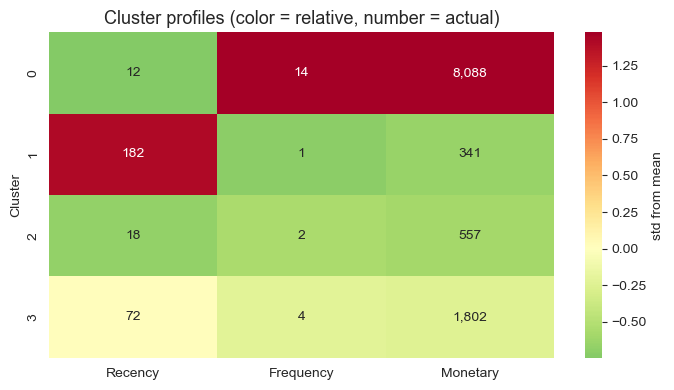

Red = worse than average for that metric, green = better. Note Recency is reversed (low recency is GOOD), so red recency = stale.


In [17]:
profile_z = cluster_profile[['Recency', 'Frequency', 'Monetary']].copy()
profile_z = (profile_z - profile_z.mean()) / profile_z.std()

plt.figure(figsize=(7, 4))
sns.heatmap(profile_z, annot=cluster_profile[['Recency', 'Frequency', 'Monetary']],
            fmt=',.0f', cmap='RdYlGn_r', center=0, cbar_kws={'label': 'std from mean'})
plt.title('Cluster profiles (color = relative, number = actual)')
plt.ylabel('Cluster'); plt.tight_layout(); plt.show()
print("Red = worse than average for that metric, green = better. "
      "Note Recency is reversed (low recency is GOOD), so red recency = stale.")

---
## 7. From clusters to personas

Cluster numbers (0, 1, 2, 3) mean nothing to a marketing team. The crucial translation step is naming each cluster based on its profile. We do this **programmatically** from the cluster centers so the labels stay correct even if K-Means assigns different numbers on a re-run (cluster IDs are not stable across runs — never hard-code them).

In [18]:
# Rank clusters by behaviour to assign stable persona names
prof = cluster_profile.copy()

# A simple "value" ordering: recent + frequent + high-spend
prof['rank_score'] = (prof['Frequency'].rank() + prof['Monetary'].rank()
                      + prof['Recency'].rank(ascending=False))
prof = prof.sort_values('rank_score', ascending=False)

persona_names = ['Champions', 'Loyal Customers', 'At-Risk', 'Hibernating']
persona_map = {cluster_id: name for cluster_id, name in zip(prof.index, persona_names)}

descriptions = {
    'Champions':       'Recent, frequent, high spend. Your revenue backbone (incl. wholesalers).',
    'Loyal Customers': 'Buy regularly and recently, moderate spend. Reliable core.',
    'At-Risk':         'Used to be good but slipping — recency climbing. Intervene NOW.',
    'Hibernating':     'Long gone, low frequency, low spend. Mostly lost.',
}

rfm['Persona'] = rfm['Cluster'].map(persona_map)
print("Cluster -> Persona mapping (data-driven, not hard-coded):")
for cid, name in persona_map.items():
    print(f"  Cluster {cid}  ->  {name}")

Cluster -> Persona mapping (data-driven, not hard-coded):
  Cluster 0  ->  Champions
  Cluster 3  ->  Loyal Customers
  Cluster 2  ->  At-Risk
  Cluster 1  ->  Hibernating


In [19]:
persona_summary = rfm.groupby('Persona').agg(
    Customers=('CustomerID', 'count'),
    Pct_of_Base=('CustomerID', lambda x: len(x) / len(rfm) * 100),
    Avg_Recency=('Recency', 'mean'),
    Avg_Frequency=('Frequency', 'mean'),
    Avg_Monetary=('Monetary', 'mean'),
    Total_Revenue=('Monetary', 'sum'),
).round(1)
persona_summary['Rev_Share_%'] = (persona_summary['Total_Revenue'] /
                                  persona_summary['Total_Revenue'].sum() * 100).round(1)
persona_summary = persona_summary.reindex(persona_names)
persona_summary

,Customers,Pct_of_Base,Avg_Recency,Avg_Frequency,Avg_Monetary,Total_Revenue,Rev_Share_%
Persona,,,,,,,
Champions,713,16.40,12.20,13.80,"8,088.00","5,766,757.10",64.90
Loyal Customers,1166,26.90,71.60,4.10,"1,801.80","2,100,873.00",23.60
At-Risk,837,19.30,17.70,2.20,557.30,"466,479.00",5.20
Hibernating,1622,37.40,181.50,1.30,341.00,"553,099.80",6.20


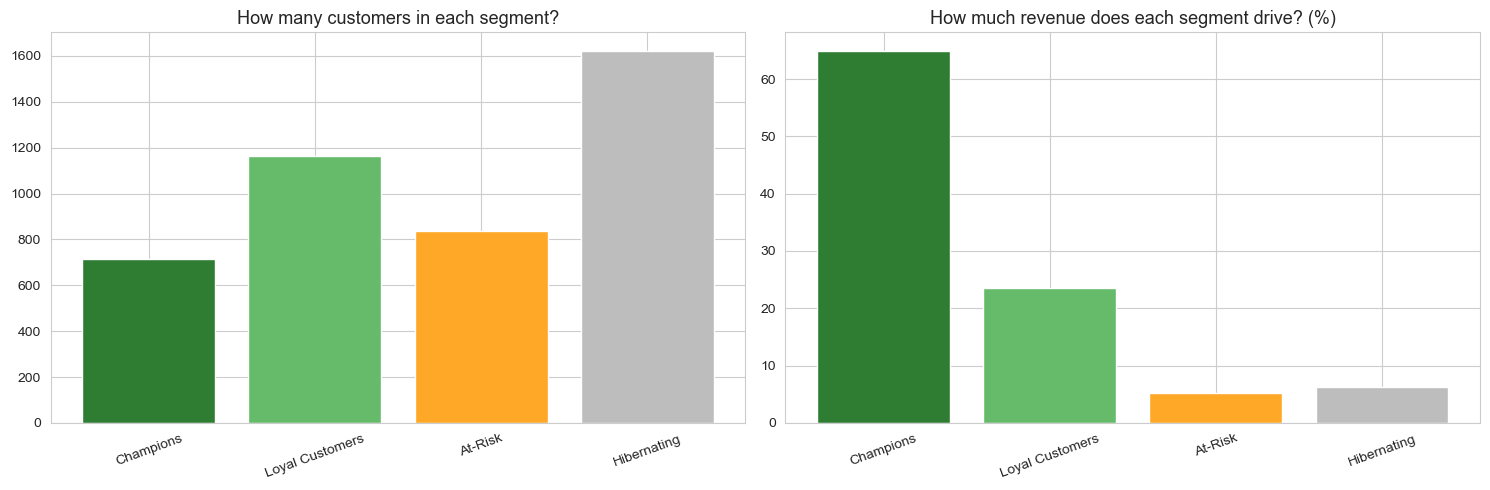

Champions are ~16% of customers but drive ~65% of revenue. This gap is the entire business case for segmentation.


In [20]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5))
colors = {'Champions': '#2e7d32', 'Loyal Customers': '#66bb6a',
          'At-Risk': '#ffa726', 'Hibernating': '#bdbdbd'}
c_list = [colors[p] for p in persona_names]

ax[0].bar(persona_names, persona_summary['Customers'], color=c_list)
ax[0].set_title('How many customers in each segment?'); ax[0].tick_params(axis='x', rotation=20)

ax[1].bar(persona_names, persona_summary['Rev_Share_%'], color=c_list)
ax[1].set_title('How much revenue does each segment drive? (%)'); ax[1].tick_params(axis='x', rotation=20)
plt.tight_layout(); plt.show()

champ_cust = persona_summary.loc['Champions', 'Pct_of_Base']
champ_rev = persona_summary.loc['Champions', 'Rev_Share_%']
print(f"Champions are ~{champ_cust:.0f}% of customers but drive ~{champ_rev:.0f}% of revenue. "
      "This gap is the entire business case for segmentation.")

---
## 8. Retention strategy — turning segments into action

Segmentation is worthless until it changes what the business *does*. Here's the playbook each persona implies. This is the slide that actually gets presented to stakeholders.

| Persona | State | Strategy | Concrete tactics |
|---|---|---|---|
| **Champions** | Best customers, buying now | **Reward & retain** | VIP perks, early access, loyalty tiers, ask for referrals/reviews. *Don't* discount — they'll pay full price. |
| **Loyal Customers** | Solid, consistent | **Grow & deepen** | Upsell/cross-sell, bundles, "you might also like", nudge toward Champion behaviour. |
| **At-Risk** | Slipping away | **Win back — urgent** | Personalized re-engagement, "we miss you" + a real incentive, survey for friction. Highest ROI on intervention. |
| **Hibernating** | Mostly lost | **Reactivate cheaply or let go** | One low-cost automated win-back email. If no response, suppress from paid channels to stop wasting budget. |

### The single most valuable insight
The **At-Risk** segment is where data science earns its keep. Champions will mostly stay regardless; Hibernating are mostly gone regardless. But At-Risk customers are at a **decision point** — a well-timed intervention measurably changes whether they churn. That's where a targeted campaign has the highest incremental ROI.

> In a follow-up project this naturally extends to a **churn prediction model** (predict *which* At-Risk customers will actually leave) and **CLV modeling** (BG/NBD + Gamma-Gamma to forecast each customer's future value), so you can size the budget you're willing to spend to save them.

In [21]:
# Export the final segmented customer table — the deliverable a CRM/marketing team consumes
output = rfm[['CustomerID', 'Recency', 'Frequency', 'Monetary',
              'RFM_Score', 'Tier', 'Cluster', 'Persona']].copy()
output.to_csv('customer_segments.csv', index=False)
print(f"Saved customer_segments.csv with {len(output):,} customers.")
output.sample(8, random_state=1)

Saved customer_segments.csv with 4,338 customers.


,CustomerID,Recency,Frequency,Monetary,RFM_Score,Tier,Cluster,Persona
3092,16565,364,1,173.70,4,05 Lost,1,Hibernating
3207,16725,302,7,758.27,9,03 Potential,3,Loyal Customers
2742,16091,155,2,315.06,7,03 Potential,1,Hibernating
1030,13739,18,1,216.90,6,04 At Risk,2,At-Risk
2830,16202,361,1,365.27,5,04 At Risk,1,Hibernating
4013,17846,85,1,"2,033.10",8,03 Potential,3,Loyal Customers
544,13062,191,1,346.98,4,05 Lost,1,Hibernating
1962,15036,72,3,429.56,8,03 Potential,3,Loyal Customers


---
## Summary — what we built

1. **Cleaned** 540K messy transaction lines into a reliable purchase history (handling cancellations, missing IDs, bad prices).
2. Engineered **RFM features** — the universal language of customer value — at the correct (per-order) granularity.
3. Shipped an interpretable **quantile-scoring baseline** first.
4. Layered **K-Means** on log-transformed, standardized features, choosing *k* with elbow + silhouette **and** business judgment.
5. Translated clusters into named **personas** programmatically (robust to label shuffling).
6. Turned each persona into a concrete **retention strategy**, with At-Risk flagged as the highest-ROI target.

### Production considerations (what changes when this is real)
- **Refresh cadence:** recompute RFM weekly/monthly; customers migrate between segments — that *migration* is itself a KPI (e.g. Champions → At-Risk is an alarm).
- **Snapshot discipline:** always use a fixed "as-of" date, never `now()`, so historical runs are reproducible and comparable.
- **Cluster drift:** the K-Means model should be periodically refit and the persona mapping re-validated; segment definitions shift as the business grows.
- **Cold start:** brand-new customers have no history — handle them with a separate rule until they have enough orders to score.
- **From descriptive to predictive:** segmentation is the foundation; churn prediction and CLV are the natural next models built on top of exactly these features.